In [1]:
import pandas as pd

# This line tells the computer to open your file
data = pd.read_csv('heart-disease.csv')

# This line tells the computer to show you the first 5 people in the list
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: >

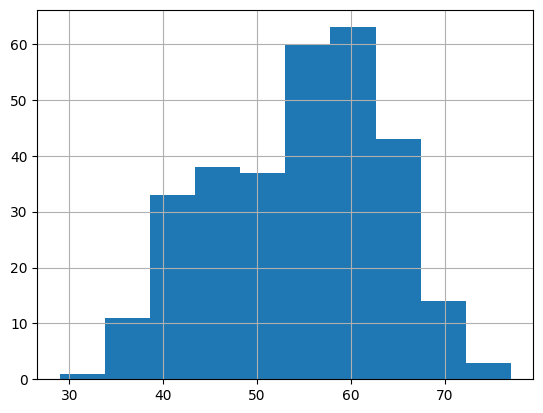

In [4]:
# This creates a histogram of ages to see who is in our study
data['age'].hist()

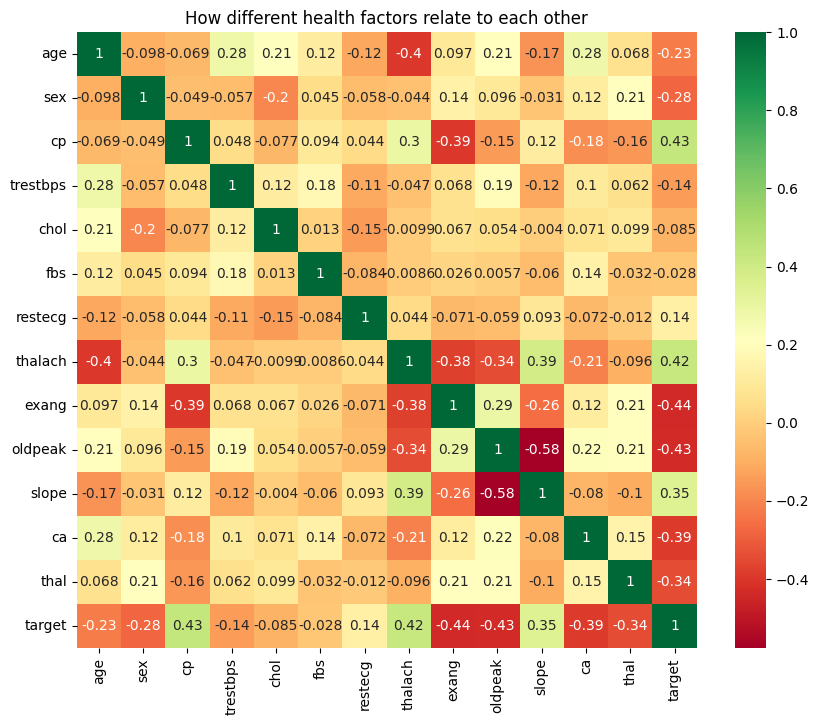

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn')
plt.title("How different health factors relate to each other")
plt.show()

In [8]:
# X = everything except the target
X = data.drop('target', axis=1)

# y = only the target
y = data['target']

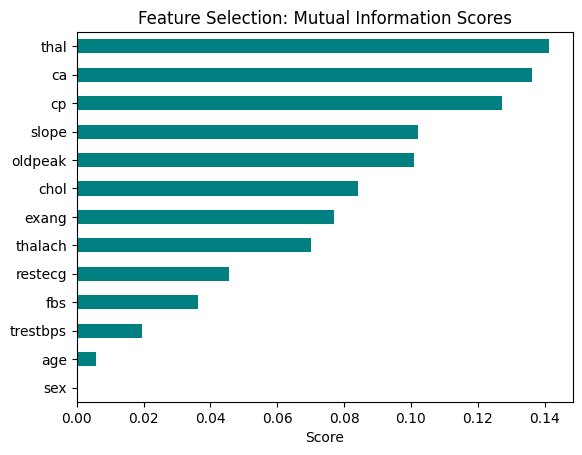

In [9]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# Calculate MI
mi_scores = mutual_info_classif(X, y, random_state=42)

# Make it look pretty in a chart
mi_results = pd.Series(mi_scores, index=X.columns)
mi_results.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Feature Selection: Mutual Information Scores")
plt.xlabel("Score")
plt.show()

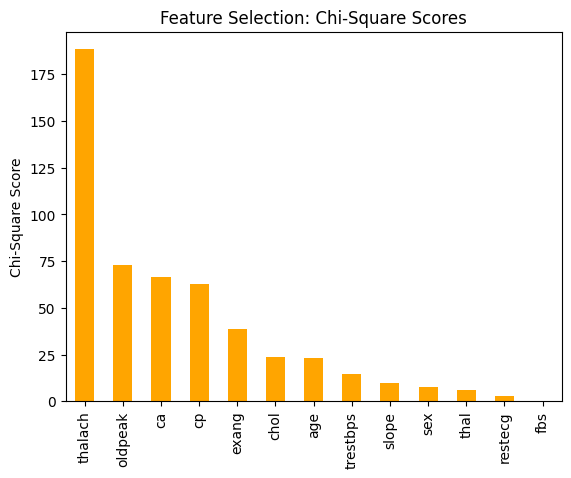

In [10]:
from sklearn.feature_selection import SelectKBest, chi2

# We pick the top 10 features
chi_selector = SelectKBest(chi2, k=10)
chi_selector.fit(X, y)

# Get the scores for each column
chi_scores = pd.Series(chi_selector.scores_, index=X.columns)
chi_scores.sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title("Feature Selection: Chi-Square Scores")
plt.ylabel("Chi-Square Score")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 1. Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

# 3. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train) # Tree-based models don't strictly need scaling
gb_acc = accuracy_score(y_test, gb.predict(X_test))

print(f"Logistic Regression: {lr_acc:.2%}")
print(f"KNN: {knn_acc:.2%}")
print(f"Gradient Boosting: {gb_acc:.2%}")

Logistic Regression: 85.25%
KNN: 90.16%
Gradient Boosting: 77.05%


/var/folders/0f/9h412c2j4jxf0vdjk8xnqm8h0000gn/T/ipykernel_90589/699637278.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


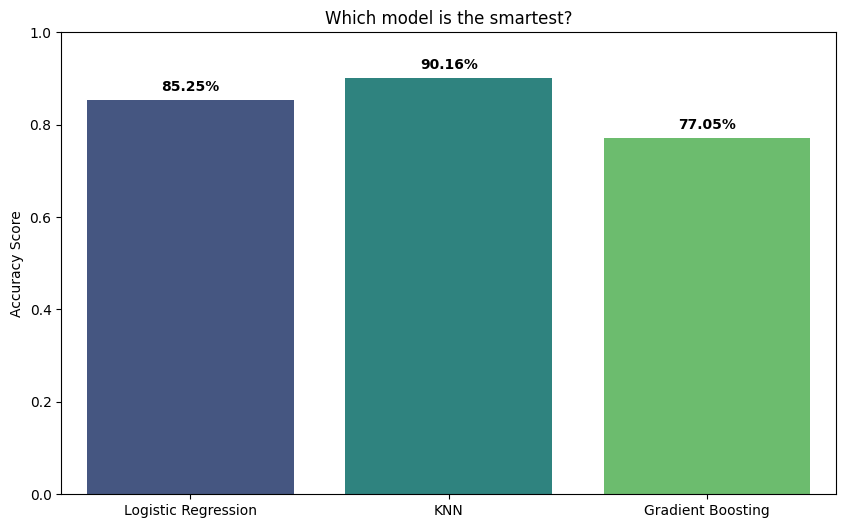

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
models = ['Logistic Regression', 'KNN', 'Gradient Boosting']
accuracies = [lr_acc, knn_acc, gb_acc]

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')

# Add labels and title
plt.ylabel('Accuracy Score')
plt.title('Which model is the smartest?')
plt.ylim(0, 1.0) # Scale from 0 to 100%

# Add the actual percentage on top of each bar
for i, val in enumerate(accuracies):
    plt.text(i, val + 0.02, f'{val:.2%}', ha='center', fontweight='bold')

plt.show()

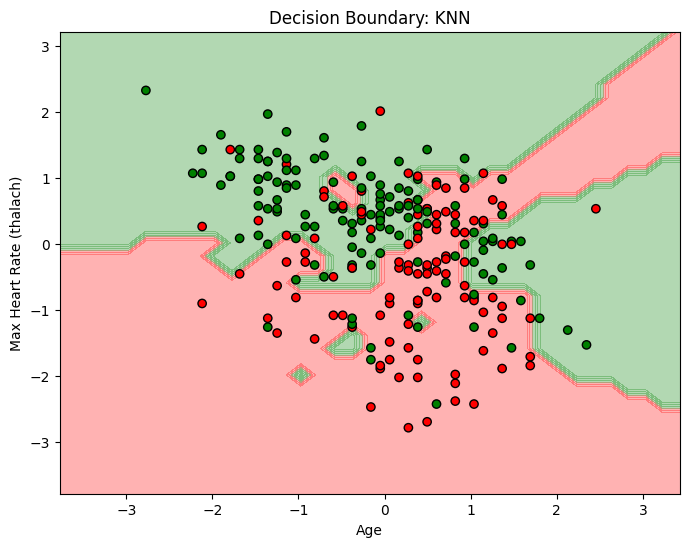

In [14]:
import numpy as np
from matplotlib.colors import ListedColormap

def plot_decision_boundaries(model, title, X, y, is_scaled=False):
    # We use Age and Max Heart Rate for the 2D plot
    # Index 0 is 'age', Index 7 is 'thalach' (check your column order!)
    X_plot = X[['age', 'thalach']].values
    y_plot = y.values
    
    # Re-train model on just these 2 features for visualization
    if is_scaled:
        from sklearn.preprocessing import StandardScaler
        X_plot = StandardScaler().fit_transform(X_plot)
        
    model.fit(X_plot, y_plot)
    
    # Create a grid to plot in
    h = .2  # step size in the mesh
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'green')))
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap=ListedColormap(('red', 'green')), edgecolors='k')
    plt.title(f"Decision Boundary: {title}")
    plt.xlabel('Age')
    plt.ylabel('Max Heart Rate (thalach)')
    plt.show()

# Run it for your best model (KNN)
plot_decision_boundaries(KNeighborsClassifier(n_neighbors=5), "KNN", X_train, y_train, is_scaled=True)

In [15]:
import pandas as pd

# This creates the 'data' variable that the computer is looking for
data = pd.read_csv('heart-disease.csv')

print("Dataset loaded successfully! 'data' is now defined.")

Dataset loaded successfully! 'data' is now defined.


In [21]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

# 1. Load data
data = pd.read_csv('heart-disease.csv')

# 2. Prep
X = data.drop('target', axis=1)
y = data['target']

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Gradient Boosting
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Print accuracy
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 7. Save
joblib.dump(model, 'heart_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Success! Gradient Boosting trained and saved due to knn not performing well.")

Accuracy: 78.69%
Success! Gradient Boosting trained and saved due to knn not performing well.
